# COGS 109 — Data Overview
## How Hyperscale Data Centers Affect Local Communities: National Panel Documentation

This notebook documents **how the dataset was built** — from naming the treated counties, to
choosing controls, to pulling and merging the federal data. It is a reading aid for the human
writers: it explains *what is in* `panel_master_national.csv` and *where every column came from*.
It does not write the paper.

**Panel:** County × Year, 2010–2024
**States:** 22 (every state with at least one hyperscale data center in our set)
**Unit of observation:** county-year
**Counties:** 169 — 45 treated, 124 control

---

### What changed from the earlier version
An earlier draft of this project studied only **3 Meta counties in OH / VA / NE**. This version
scales up to a **national** set of 45 hyperscale-data-center counties (Meta, Google, AWS,
Microsoft, Apple, Oracle) plus 124 matched controls, and adds two COVID-era data sources. The
national design is what the analysis notebook now uses; the old 3-state files are superseded.

## Phase 1 — Treated counties (the national hyperscale list)

We identified every U.S. county that received a **hyperscale** data center (Meta, Google, AWS,
Microsoft, Apple, Oracle), with a verified first-operational year and exact county FIPS code.
Colocation / enterprise facilities were excluded (their opening dates are unreliable and the
"treatment" is ambiguous). The result is `data/raw/treatment_national.csv` — **45 counties**.

A county's treatment year is the **earliest** hyperscaler to open there. Counties are tagged for
edge cases: pre-2010 openings (no clean pre-period), post-2022 openings (not operational in our
window), multiple operators (compound treatment), huge-metro (effect dilutes), and county-border
FIPS ambiguity.

In [1]:
import pandas as pd, numpy as np
pd.set_option('display.width', 160)

trt = pd.read_csv('data/raw/treatment_national.csv', dtype={'fips': str})
print(f'Treated counties: {len(trt)}')
print(f'Primary operators:\n{trt.operator.value_counts().to_string()}')

# opening-year buckets
def bucket(y):
    y = int(y)
    if y < 2010: return 'pre-2010 (no clean pre-period)'
    if y <= 2018: return '2010-2018'
    if y <= 2022: return '2019-2022'
    return 'post-2022 (excluded from analysis)'
print('\nOpening-year buckets:')
print(trt.dc_opening_year.apply(bucket).value_counts().reindex(
    ['pre-2010 (no clean pre-period)','2010-2018','2019-2022','post-2022 (excluded from analysis)']).to_string())
trt[['fips','county','state','operator','dc_opening_year','opening_year_confidence']].head(10)

Treated counties: 45
Primary operators:
operator
Google       12
Meta         12
AWS          10
Microsoft     6
Apple         4
Oracle        1

Opening-year buckets:
dc_opening_year
pre-2010 (no clean pre-period)        13
2010-2018                             14
2019-2022                             12
post-2022 (excluded from analysis)     6


,fips,county,state,operator,dc_opening_year,opening_year_confidence
0,13097,Douglas County,GA,Google,2003,low
1,06001,Alameda County,CA,Apple,2006,high
2,41065,Wasco County,OR,Google,2006,high
3,51059,Fairfax County,VA,AWS,2006,high
4,51107,Loudoun County,VA,AWS,2006,high
5,53025,Grant County,WA,Microsoft,2007,high
6,37027,Caldwell County,NC,Google,2008,medium
7,45015,Berkeley County,SC,Google,2008,medium
8,48029,Bexar County,TX,Microsoft,2008,high
9,06085,Santa Clara County,CA,AWS,2009,medium


## Phase 2 — Control counties + the master list

Controls must be plausibly comparable to treated counties but **untreated during 2010–2022**. We:

1. Pulled 2019 county population for all 1,770 counties in the 22 treated states.
2. Kept candidates in the treated-county **population band** (~25k to ~1.15M), **same states** as
   treated (so state fixed effects and shared electricity markets stay meaningful).
3. Sampled ~4 controls per in-panel treated county (seed 42), matched on population.
4. **Web-checked every candidate** for data-center presence. Counties with a DC *operational during
   2010–2022* were dropped and back-filled; counties with only a *post-panel (2023+)* announcement
   were kept but tagged `FUTURE_DC_2023plus`.

The combined output is `data/raw/county_master_list.csv` — 169 counties with two analysis flags:
- `analysis_diD = 1` → usable in the difference-in-differences (in-panel treated + controls)
- `classifier_dc = 1` → had an operational DC in-panel (used as the classifier label)

In [2]:
m = pd.read_csv('data/raw/county_master_list.csv', dtype={'fips': str})
print(f'Total counties: {len(m)}  ({(m.role=="treated").sum()} treated, {(m.role=="control").sum()} control)')
print(f'DiD analysis set (analysis_diD=1): {(m.analysis_diD==1).sum()}')
print(f'Classifier positives (classifier_dc=1): {(m.classifier_dc==1).sum()}')

flags = m.cohort_flags.fillna('')
print('\nTreated-county cohorts:')
print(f'  in-panel treated (2010-2022, in DiD): {((m.role=="treated")&(m.analysis_diD==1)).sum()}')
print(f'  always-treated (pre-2010, DiD-excluded): {flags.str.contains("ALWAYS_TREATED").sum()}')
print(f'  post-2022 treated (excluded both): {flags.str.contains("POST_PANEL").sum()}')
print(f'\nControls tagged FUTURE_DC_2023plus: {flags.str.contains("FUTURE_DC_2023plus").sum()}')
print(f'Counties per state:\n{m.fips.str[:2].map({"01":"AL","04":"AZ","06":"CA","13":"GA","17":"IL","18":"IN","19":"IA","29":"MO","31":"NE","32":"NV","35":"NM","37":"NC","39":"OH","40":"OK","41":"OR","45":"SC","47":"TN","48":"TX","49":"UT","51":"VA","53":"WA","56":"WY"}).value_counts().to_string()}')

Total counties: 169  (45 treated, 124 control)
DiD analysis set (analysis_diD=1): 150
Classifier positives (classifier_dc=1): 39

Treated-county cohorts:
  in-panel treated (2010-2022, in DiD): 26
  always-treated (pre-2010, DiD-excluded): 13
  post-2022 treated (excluded both): 6

Controls tagged FUTURE_DC_2023plus: 29
Counties per state:
fips
VA    21
OR    16
OH    15
NC    11
TX    11
AL    10
UT     8
NM     8
NV     8
IA     7
AZ     6
TN     6
GA     6
NE     5
OK     5
WY     5
IN     4
IL     4
CA     4
MO     3
SC     3
WA     3


## Phase 3 — Federal data sources merged into the panel

Five federal sources (the original five) plus **two new COVID-era sources** were pulled for all
169 counties and merged on `(fips, year)` into `data/panel_master_national.csv`.

| Source | Columns | Coverage |
|---|---|---|
| **Census ACS** 5-yr | median_income, poverty_rate, pct_bachelors, pop_density, unemployment_acs, median_age | 2010–2023 |
| **BEA** | per_capita_income, gdp_thousands | 2010–2024 |
| **BLS LAUS** | unemployment_rate, labor_force | 2010–2022 |
| **BLS QCEW** | total_employment, total_wages, avg_annual_wage, data_processing_employment, total_establishments | 2010–2024 |
| **EIA Form 861** | elec_rate_cents_kwh (customer-weighted to county) | 2010–2022, 2024 |
| **NYT COVID** *(new)* | covid_deaths_per_100k, covid_cases_per_100k | 2020–2023 (0 before) |
| **Census ACS B08301** *(new)* | wfh_rate (% working from home) | 2010–2023 |

The two COVID-era columns are the **direct pandemic controls** — they let the analysis address the
"isn't this just COVID?" question head-on instead of only absorbing it in year fixed effects.

End years are ragged because sources release on different schedules (LAUS stops at 2022, ACS at
2023, EIA is missing its 2023 file). This is expected and handled by listwise deletion downstream.
See `data/data_quality_report_national.md` for the full per-column missingness audit.

In [3]:
p = pd.read_csv('data/panel_master_national.csv', dtype={'fips': str})
print(f'Panel shape: {p.shape}  ({p.fips.nunique()} counties x {p.year.nunique()} years)')
print(f'Years: {p.year.min()}-{p.year.max()}')

# the COVID/WFH columns — the new pandemic controls — by year
print('\nCOVID & work-from-home means by year (the new controls):')
chk = p.groupby('year')[['covid_deaths_per_100k','covid_cases_per_100k','wfh_rate']].mean().round(2)
print(chk.to_string())

Panel shape: (2535, 35)  (169 counties x 15 years)
Years: 2010-2024

COVID & work-from-home means by year (the new controls):
      covid_deaths_per_100k  covid_cases_per_100k  wfh_rate
year                                                       
2010                   0.00                  0.00      4.01
2011                   0.00                  0.00      4.11
2012                   0.00                  0.00      4.11
2013                   0.00                  0.00      4.14
2014                   0.00                  0.00      4.14
2015                   0.00                  0.00      4.17
2016                   0.00                  0.00      4.29
2017                   0.00                  0.00      4.43
2018                   0.00                  0.00      4.58
2019                   0.00                  0.00      4.78
2020                  82.38               6278.93      6.30
2021                 161.29              10567.86      8.11
2022                  96.13       

### Sanity check on the COVID controls

Two things should be visible above, and both are:

- **`covid_*` is exactly 0 for 2010–2019** and jumps in 2020, peaking in **2021** (~161 deaths /
  100k) before falling — the correct pandemic shape.
- **`wfh_rate` rises** from ~4% (flat pre-pandemic) to ~10% by 2023.

One caveat the writers should know: ACS `wfh_rate` is a **5-year rolling average**, so it *smears*
the 2020–2021 spike across vintages and understates the true single-year jump. It is still the only
work-from-home series available for all 169 small counties, and the upward break is unmistakable.

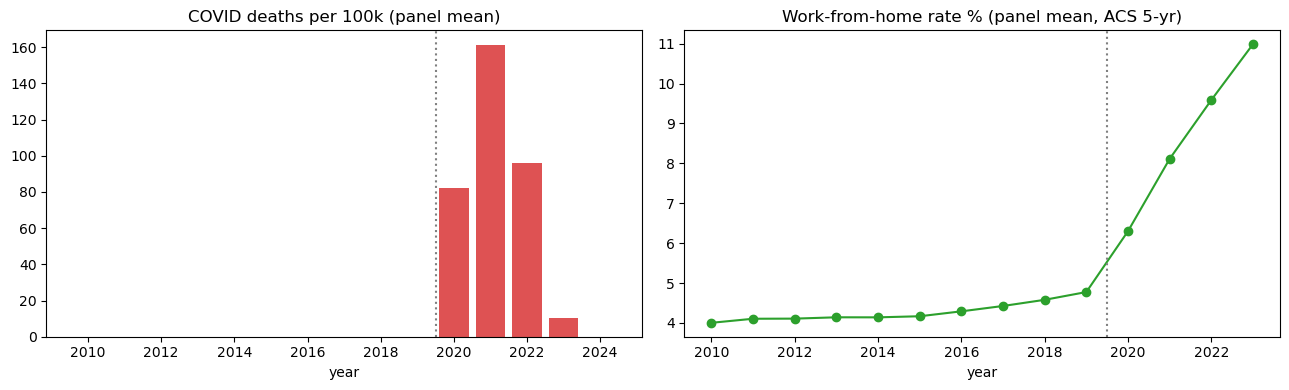

In [4]:
# Visual: COVID deaths and WFH over time
import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
g = p.groupby('year')[['covid_deaths_per_100k','wfh_rate']].mean()
a1.bar(g.index, g['covid_deaths_per_100k'], color='tab:red', alpha=0.8)
a1.set_title('COVID deaths per 100k (panel mean)'); a1.set_xlabel('year'); a1.axvline(2019.5, color='gray', ls=':')
a2.plot(g.index, g['wfh_rate'], 'o-', color='tab:green'); a2.axvline(2019.5, color='gray', ls=':')
a2.set_title('Work-from-home rate % (panel mean, ACS 5-yr)'); a2.set_xlabel('year')
plt.tight_layout(); plt.show()

## Positive-control pool (for the classifier diagnostic, not the study panel)

One extra dataset sits outside the main panel: `data/raw/unmatched_pool_baseline.csv`. It is **not**
part of the 169-county study panel and is never merged into it — it exists only to calibrate the
selection classifier (see the "positive control" section of `analysis.ipynb`).

It is a sample of **400 random counties** drawn from the same 22 states (seed 42, proportional to
each state's county count), **excluding** every county in the master list and every treated county.
For these counties we pulled only the **2010–2012 baseline means** of the 9 classifier features —
entirely from the already-cached raw files (no new API calls). The classifier uses this unmatched
pool as a negative class to check whether the pipeline can detect data-center selection *at all* when
population/state matching is not in the way.

In [5]:
pool = pd.read_csv('data/raw/unmatched_pool_baseline.csv', dtype={'fips': str})
print(f'Positive-control pool: {len(pool)} counties (baseline-only, not in the study panel)')
print(f'States represented: {pool.state.nunique()}')
feats = ['per_capita_income','total_employment','avg_annual_wage','elec_rate_cents_kwh',
         'poverty_rate','unemployment_rate','pop_density','median_age','pct_bachelors']
print('\nPer-feature coverage (non-NaN / 400):')
for f in feats:
    n = pool[f].notna().sum()
    print(f'  {f:22s} {n}/400  ({100*n/len(pool):.0f}%)')
print('\nAll from cache; income & electricity at 98% (VA combined-area cases), the rest 100%.')

Positive-control pool: 400 counties (baseline-only, not in the study panel)
States represented: 22

Per-feature coverage (non-NaN / 400):
  per_capita_income      390/400  (98%)
  total_employment       400/400  (100%)
  avg_annual_wage        400/400  (100%)
  elec_rate_cents_kwh    390/400  (98%)
  poverty_rate           400/400  (100%)
  unemployment_rate      400/400  (100%)
  pop_density            400/400  (100%)
  median_age             400/400  (100%)
  pct_bachelors          400/400  (100%)

All from cache; income & electricity at 98% (VA combined-area cases), the rest 100%.


## Where to go next

- **`analysis.ipynb`** — the difference-in-differences results, the COVID-controlled specification,
  the event study, and the selection classifier (Phases 4–5).
- **`00_summary.ipynb`** — the one-page overview tying both notebooks together with the headline numbers.
- **`data/data_quality_report_national.md`** — full missingness / coverage audit.
- **`data/raw/*_national_notes.md`** — per-source provenance notes.